In [ ]:
# Imports & paths
from pathlib import Path
import json, math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Base folder containing multiple experiments
SCHEDULE_ROOT = Path('../results/2025-12-03_20-10-52_schedule_8exp').resolve()
EXPERIMENT_DIRS = [p for p in sorted(SCHEDULE_ROOT.iterdir()) if p.is_dir()]

# Per-experiment detection metrics roots
DET_METRICS_ROOTS = {p.name: p / 'test' / 'detection' / 'metrics' for p in EXPERIMENT_DIRS}

# Per-experiment segmentation roots: find predictions/*/YOLOv11 (model subdir varies: unetpp/medsam/automask/etc.)
SEG_ROOTS = {}
for p in EXPERIMENT_DIRS:
    pred_base = p / 'test' / 'segmentation' / 'predictions'
    seg_root = None
    if pred_base.exists():
        # search one level under predictions for the model folder, then YOLOv11
        for model_dir in sorted(pred_base.iterdir()):
            candidate = model_dir / 'YOLOv11'
            if candidate.exists():
                seg_root = candidate
                break
        # fallback: if predictions/YOLOv11 exists directly
        direct = pred_base / 'YOLOv11'
        if seg_root is None and direct.exists():
            seg_root = direct
    SEG_ROOTS[p.name] = seg_root if seg_root else pred_base / 'YOLOv11'  # keep path even if missing for later check

print('Schedule root:', SCHEDULE_ROOT)
print('Experiments found:', len(EXPERIMENT_DIRS))
for name, root in list(SEG_ROOTS.items())[:3]:
    print(' -', name, '| seg root exists:', root.exists())

Schedule root: C:\Users\User\Desktop\code\Traking\results\2025-12-03_20-10-52_schedule_8exp
Experiments found: 8
 - 2025-12-03_20-10-52_clahe_yolov11_unetpp
 - 2025-12-03_20-16-21_yolov11_unetpp
 - 2025-12-03_20-21-23_clahe_yolov11_medsam


In [ ]:
# Helpers to load detection per-frame metrics (JSON preferred, CSV fallback) across experiments
def load_json(path: Path):
    try:
        with path.open('r', encoding='utf-8') as fh:
            return json.load(fh)
    except Exception:
        return None


def load_detection_per_frame(metrics_roots: dict) -> pd.DataFrame:
    records = []
    for exp_name, metrics_root in metrics_roots.items():
        if not metrics_root.exists():
            continue
        for video_dir in sorted(metrics_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            json_candidates = sorted(video_dir.glob('*_per_frame.json'))
            per_frame = None
            for cand in json_candidates:
                per_frame = load_json(cand)
                if per_frame:
                    break
            if per_frame:
                for frame_str, vals in per_frame.items():
                    try:
                        fi = int(frame_str)
                    except Exception:
                        continue
                    ce = vals.get('ce')
                    iou = vals.get('iou')
                    records.append({'experiment': exp_name, 'video': video, 'frame': fi, 'det_ce': ce, 'det_iou': iou})
                continue
            # CSV fallback
            csv_candidates = sorted(video_dir.glob('*_per_frame.csv'))
            for csv_path in csv_candidates:
                df_csv = pd.read_csv(csv_path)
                ce_col = None
                for col in df_csv.columns:
                    if str(col).lower() in {'center_error', 'ce'}:
                        ce_col = col
                        break
                if ce_col is None and len(df_csv.columns) >= 3:
                    ce_col = df_csv.columns[2]
                fi_col = df_csv.columns[0]
                iou_col = df_csv.columns[1] if len(df_csv.columns) > 1 else None
                for _, row in df_csv.iterrows():
                    if pd.isna(row.get(fi_col)):
                        continue
                    try:
                        fi = int(row[fi_col])
                    except Exception:
                        continue
                    ce = row.get(ce_col) if ce_col in row else None
                    iou = row.get(iou_col) if (iou_col and iou_col in row) else None
                    records.append({
                        'experiment': exp_name,
                        'video': video,
                        'frame': fi,
                        'det_ce': float(ce) if pd.notna(ce) else None,
                        'det_iou': float(iou) if (iou_col and pd.notna(iou)) else None
                    })
    return pd.DataFrame(records)

# Optional: raw detection metrics (bbox-center vs GT bbox-center); downstream overridden by centroid-based CE
det_df_raw = load_detection_per_frame(DET_METRICS_ROOTS)
det_df_raw.head()

,experiment,video,frame,det_ce,det_iou
0,2025-12-03_20-10-52_clahe_yolov11_unetpp,001Grasp,0,11.199619,0.704277
1,2025-12-03_20-10-52_clahe_yolov11_unetpp,001Grasp,14,12.639818,0.710144
2,2025-12-03_20-10-52_clahe_yolov11_unetpp,001Grasp,29,4.671719,0.850269
3,2025-12-03_20-10-52_clahe_yolov11_unetpp,001Grasp,44,8.777520,0.808380
4,2025-12-03_20-10-52_clahe_yolov11_unetpp,001Grasp,59,3.243401,0.854995


In [ ]:
# Helpers to load segmentation per-frame metrics (centroid error vs GT) across experiments
def load_segmentation_per_frame(seg_roots: dict) -> pd.DataFrame:
    records = []
    for exp_name, seg_root in seg_roots.items():
        if not seg_root.exists():
            continue
        for video_dir in sorted(seg_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            metrics_path = video_dir / 'metrics_per_frame.json'
            data = load_json(metrics_path) or {}
            for frame_str, vals in data.items():
                try:
                    fi = int(frame_str)
                except Exception:
                    continue
                records.append({
                    'experiment': exp_name,
                    'video': video,
                    'frame': fi,
                    'seg_centroid': vals.get('centroid'),
                    'seg_iou': vals.get('iou'),
                    'seg_dice': vals.get('dice'),
                })
    return pd.DataFrame(records)

seg_df = load_segmentation_per_frame(SEG_ROOTS)
seg_df.head()

""


In [ ]:
# Compute detection center error vs GT centroid using GT masks across experiments
from PIL import Image

GT_MASK_ROOT = Path('../dataset/超音波檔案-20251126T083302Z-1-001/seg_masks').resolve()


def mask_centroid(mask_path: Path):
    arr = np.array(Image.open(mask_path).convert('L'))
    ys, xs = np.nonzero(arr)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())


def load_gt_centroids(video_names) -> pd.DataFrame:
    records = []
    for video in sorted(video_names):
        vdir = GT_MASK_ROOT / video
        if not vdir.exists():
            continue
        for mask_path in sorted(vdir.glob('frame_*.png')):
            stem = mask_path.stem.split('_')[-1]
            try:
                frame_raw = int(stem)
            except Exception:
                continue
            frame_idx = max(frame_raw - 1, 0)  # mask filenames are 1-based
            cent = mask_centroid(mask_path)
            if cent is None:
                continue
            records.append({'video': video, 'frame': frame_idx, 'gt_cx': cent[0], 'gt_cy': cent[1]})
    return pd.DataFrame(records)


def load_det_centers(exp_dirs) -> pd.DataFrame:
    records = []
    for exp_dir in exp_dirs:
        exp_name = exp_dir.name
        pred_root = exp_dir / 'test' / 'detection' / 'predictions_by_video'
        if not pred_root.exists():
            continue
        for video_dir in sorted(pred_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            pred_path = video_dir / 'YOLOv11.json'
            if not pred_path.exists():
                continue
            preds = load_json(pred_path) or []
            for item in preds:
                fi = item.get('frame_index')
                bbox = item.get('bbox')
                if fi is None or bbox is None or len(bbox) < 4:
                    continue
                x, y, w, h = bbox[:4]
                cx = x + w / 2.0
                cy = y + h / 2.0
                records.append({'experiment': exp_name, 'video': video, 'frame': int(fi), 'det_cx': float(cx), 'det_cy': float(cy)})
    return pd.DataFrame(records)


det_centers = load_det_centers(EXPERIMENT_DIRS)
gt_centers = load_gt_centroids(det_centers['video'].unique())

det_centroid_df = pd.merge(det_centers, gt_centers, on=['video', 'frame'], how='inner')
det_centroid_df['det_ce'] = np.sqrt(
    (det_centroid_df['det_cx'] - det_centroid_df['gt_cx']) ** 2 + (det_centroid_df['det_cy'] - det_centroid_df['gt_cy']) ** 2
)
det_centroid_df = det_centroid_df[['experiment', 'video', 'frame', 'det_ce', 'det_cx', 'det_cy', 'gt_cx', 'gt_cy']]

print('Detection frames with GT centroid:', len(det_centroid_df))
# Override det_df for downstream merge to use centroid-based detection CE
det_df = det_centroid_df


Detection frames with GT centroid: 672


In [ ]:
# Sanity check columns before merge
if 'experiment' not in det_df.columns:
    det_df['experiment'] = SCHEDULE_ROOT.name
if 'experiment' not in seg_df.columns:
    seg_df['experiment'] = SCHEDULE_ROOT.name
print('det_df cols:', det_df.columns.tolist())
print('seg_df cols:', seg_df.columns.tolist())

det_df cols: ['experiment', 'video', 'frame', 'det_ce', 'det_cx', 'det_cy', 'gt_cx', 'gt_cy']
seg_df cols: ['experiment']


In [ ]:
# Merge detection and segmentation metrics on (experiment, video, frame)
req_det = {'experiment', 'video', 'frame', 'det_ce'}
req_seg = {'experiment', 'video', 'frame', 'seg_centroid'}
missing_det = req_det - set(det_df.columns)
missing_seg = req_seg - set(seg_df.columns)
if missing_det:
    raise ValueError(f"det_df missing columns: {missing_det}")
if missing_seg:
    raise ValueError(f"seg_df missing columns: {missing_seg}")

merged = pd.merge(det_df, seg_df, on=['experiment', 'video', 'frame'], how='inner')
merged = merged.sort_values(['experiment', 'video', 'frame']).reset_index(drop=True)
print('Rows merged:', len(merged))
merged.head()

In [ ]:
# Overall aggregates across all experiments/videos/frames
overall = {
    'n_rows': len(merged),
    'det_ce_mean': merged['det_ce'].mean(),
    'det_ce_median': merged['det_ce'].median(),
    'seg_centroid_mean': merged['seg_centroid'].mean(),
    'seg_centroid_median': merged['seg_centroid'].median(),
    'delta_mean': (merged['det_ce'] - merged['seg_centroid']).mean(),
    'delta_median': (merged['det_ce'] - merged['seg_centroid']).median(),
}
print(overall)

per_exp = merged.groupby('experiment')[['det_ce','seg_centroid']].mean().rename(columns={'det_ce':'det_ce_mean','seg_centroid':'seg_centroid_mean'})
print('\nPer-experiment means (det_ce vs seg_centroid):')
print(per_exp)


In [ ]:
# Section 1: 基本統計
summary = {
    'count': len(merged),
    'det_ce_mean': merged['det_ce'].mean(),
    'seg_centroid_mean': merged['seg_centroid'].mean(),
    'det_ce_median': merged['det_ce'].median(),
    'seg_centroid_median': merged['seg_centroid'].median(),
}
summary

{'count': 84,
 'det_ce_mean': np.float64(10.387642535935127),
 'seg_centroid_mean': np.float64(10.295625514092139),
 'det_ce_median': np.float64(4.651898456669214),
 'seg_centroid_median': np.float64(4.34020875122914)}

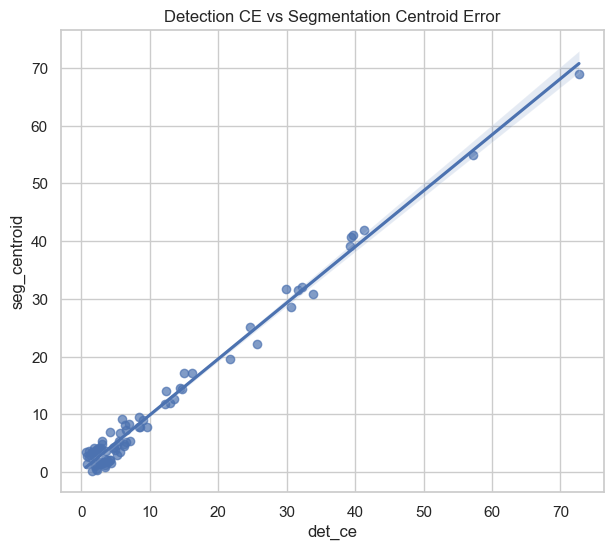

{'pearson_r': np.float64(0.9922622406915687), 'pearson_p': np.float64(4.502277420095636e-76), 'spearman_r': np.float64(0.8446896831021566), 'spearman_p': np.float64(5.715155925273621e-24)}


In [ ]:
# Section 2: 相關性與迴歸線
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(7, 6))
sns.regplot(data=merged, x='det_ce', y='seg_centroid', scatter_kws={'alpha':0.7}, ax=ax)
ax.set_title('Detection CE vs Segmentation Centroid Error')
plt.show()

pearson_r, pearson_p = stats.pearsonr(merged['det_ce'], merged['seg_centroid'])
spearman_r, spearman_p = stats.spearmanr(merged['det_ce'], merged['seg_centroid'])
print({'pearson_r': pearson_r, 'pearson_p': pearson_p, 'spearman_r': spearman_r, 'spearman_p': spearman_p})

In [ ]:
# Section 3: 質心誤差比較與配對檢定
merged['delta'] = merged['det_ce'] - merged['seg_centroid']  # >0 means segmentation better

ttest_res = stats.ttest_rel(merged['det_ce'], merged['seg_centroid'])
try:
    wilcoxon_res = stats.wilcoxon(merged['det_ce'], merged['seg_centroid'])
except Exception as exc:
    wilcoxon_res = {'statistic': math.nan, 'pvalue': math.nan, 'error': str(exc)}

summary_cmp = pd.DataFrame({
    'metric': ['mean', 'median', 'std', 'p25', 'p75'],
    'det_ce': [merged['det_ce'].mean(), merged['det_ce'].median(), merged['det_ce'].std(), merged['det_ce'].quantile(0.25), merged['det_ce'].quantile(0.75)],
    'seg_centroid': [merged['seg_centroid'].mean(), merged['seg_centroid'].median(), merged['seg_centroid'].std(), merged['seg_centroid'].quantile(0.25), merged['seg_centroid'].quantile(0.75)],
    'delta (det - seg)': [merged['delta'].mean(), merged['delta'].median(), merged['delta'].std(), merged['delta'].quantile(0.25), merged['delta'].quantile(0.75)],
})

print('Paired t-test p-value:', ttest_res.pvalue)
print('Wilcoxon p-value:', getattr(wilcoxon_res, 'pvalue', wilcoxon_res))
summary_cmp

Paired t-test p-value: 0.6221503946614819
Wilcoxon p-value: 0.6491831440606595


,metric,det_ce,seg_centroid,delta (det - seg)
0,mean,10.387643,10.295626,0.092017
1,median,4.651898,4.340209,0.269938
2,std,13.639216,13.336133,1.704925
3,p25,2.616060,2.796488,-1.485954
4,p75,12.302567,11.809886,1.541839


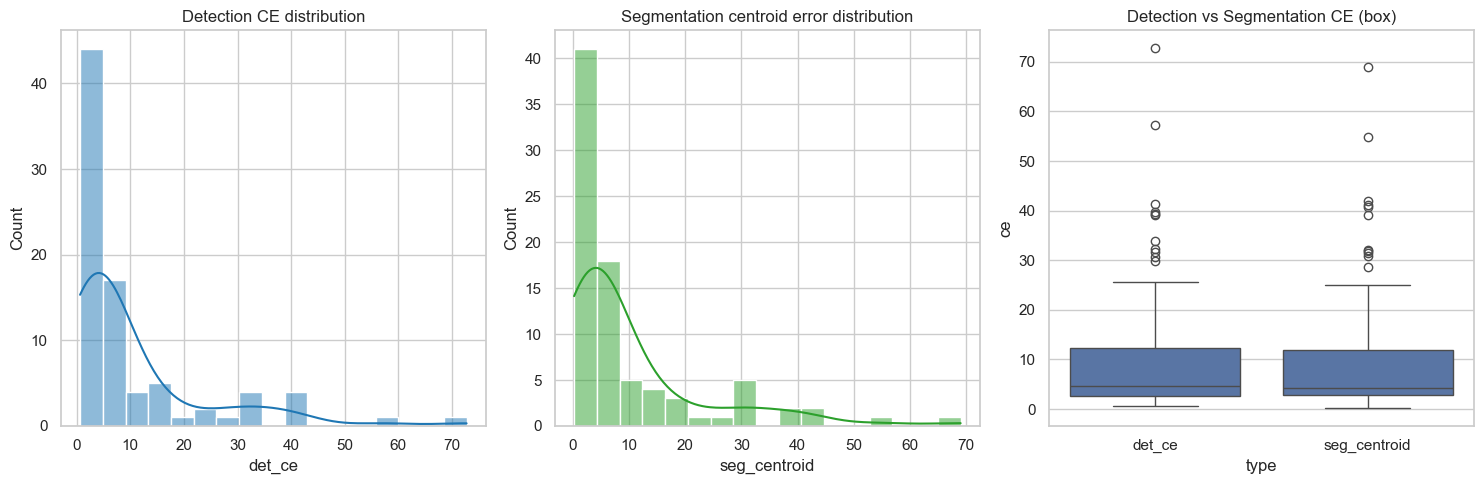

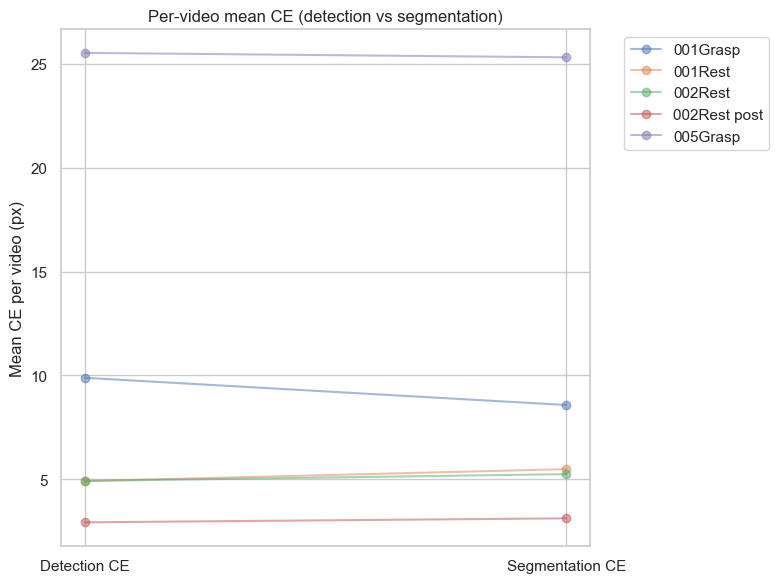

In [ ]:
# Section 4: 視覺化誤差分佈與配對差異
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(merged['det_ce'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Detection CE distribution')
sns.histplot(merged['seg_centroid'], kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Segmentation centroid error distribution')
sns.boxplot(data=merged.melt(value_vars=['det_ce', 'seg_centroid'], var_name='type', value_name='ce'), x='type', y='ce', ax=axes[2])
axes[2].set_title('Detection vs Segmentation CE (box)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
merged['video_label'] = merged['experiment'] + ':' + merged['video']
for vid_label, group in merged.groupby('video_label'):
    plt.plot([0, 1], [group['det_ce'].mean(), group['seg_centroid'].mean()], marker='o', alpha=0.5, label=vid_label)
plt.xticks([0, 1], ['Detection CE', 'Segmentation CE'])
plt.ylabel('Mean CE per video (px)')
plt.title('Per-video mean CE (detection vs segmentation)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [ ]:
# Section 5: 結論性摘要表
report = {
    'n_frames': len(merged),
    'mean_det_ce': merged['det_ce'].mean(),
    'mean_seg_ce': merged['seg_centroid'].mean(),
    'median_det_ce': merged['det_ce'].median(),
    'median_seg_ce': merged['seg_centroid'].median(),
    'pearson_r': pearson_r,
    'pearson_p': pearson_p,
    'spearman_r': spearman_r,
    'spearman_p': spearman_p,
    'paired_t_p': ttest_res.pvalue,
    'wilcoxon_p': getattr(wilcoxon_res, 'pvalue', np.nan),
    'frac_seg_better': float((merged['delta'] > 0).mean()),
    'mean_delta_det_minus_seg': merged['delta'].mean(),
}
pd.DataFrame([report])

,n_frames,mean_det_ce,mean_seg_ce,median_det_ce,median_seg_ce,pearson_r,pearson_p,spearman_r,spearman_p,paired_t_p,wilcoxon_p,frac_seg_better,mean_delta_det_minus_seg
0,84,10.387643,10.295626,4.651898,4.340209,0.992262,4.502277e-76,0.84469,5.715156e-24,0.62215,0.649183,0.547619,0.092017


## 使用說明
1. 依序執行各 cell；若缺少套件可在 notebook 內安裝（例如 `pip install seaborn scipy`）。
2. `merged` DataFrame 已含每個 video/frame 的 detection CE 與 segmentation centroid error，可再自訂視覺化。
3. 關注 `report` 與 `summary_cmp`：`mean_delta_det_minus_seg` > 0 且配對檢定 p-value 顯著，表示 segmentation 比 bbox 更能降低質心誤差。